# Імітаційна модель задачі планування часу
Побудувати імітаційну модель появи 𝐾 клієнтів з 𝑀𝑘 запитами для віртуального вузла.

Поява клієнтів носить випадковий характер, система попереднього запису відсутня.

Віртуальний вузол може обслуговувати тільки один запит, який може надходити у визначений момент часу. Але існує варіант розміщення на додатковому ресурсі черги з 𝑁 запитів (𝑁 ≥ 1), які були відхилені.

Змінними є величини:
- 𝑥1 = {0 сек., 5 сек., 7 сек. } - інтервали часу між послідовними моментами появ запитів;
- 𝑥2 = {10 сек., 15 сек., 20 сек. , 25 сек. } - час оброблення запиту клієнта, поява кожного значення рівноймовірно;

Ймовірність виникнення кожної з елементарних подій припустити довільними.

Розглянути імітаційні моделі при:
1) 𝐾 = 1000 , 𝑀𝑘 = 1 , 𝑁 = 50;
2) 𝐾 = 5 , 𝑀𝑘 = 2𝐾 , 𝑁 = 𝐾, черга з пріоритетами (пріоритет – мінімальна кількість запитів від клієнта).

Використати генератор випадкових чисел:
1) рівномірний розподіл (якщо остання цифра залікової книжки здобувача – парне число);
2) експоненціальний розподіл (якщо остання цифра залікової книжки здобувача – непарне число).

In [7]:
import matplotlib.pyplot as plt
import random
from typing import Optional

In [8]:
class Request:
    def __init__(self, arrival_time: float, service_time: float):
        """
        Represents a request in the system.

        :param arrival_time: Time when the request arrives.
        :param service_time: Time required to service the request.
        """

        self.arrival_time = arrival_time
        self.service_time = service_time
        self.start_time = None
        self.end_time = None


class VirtualNode:
    def __init__(self, max_queue_size: int):
        """
        Represents the virtual node system.

        :param max_queue_size: Maximum size of the queue.
        """

        self.max_queue_size = max_queue_size
        self.queue: list[Request] = []
        self.current_request: Optional[Request] = None
        self.clock = 0.0
        self.rejected_requests = 0
        self.processed_requests = 0
        self.queue_sizes = []

    def process_request(self, request: Request):
        if not self.current_request:
            self.current_request = request
            request.start_time = max(self.clock, request.arrival_time)
            request.end_time = request.start_time + request.service_time
        elif len(self.queue) < self.max_queue_size:
            self.queue.append(request)
        else:
            self.rejected_requests += 1

    def update(self):
        if self.current_request and self.clock >= self.current_request.end_time:
            self.processed_requests += 1
            self.current_request = None

            if self.queue:
                next_request = self.queue.pop(0)
                self.process_request(next_request)

    def run_simulation(self, requests: list[Request]):
        for request in requests:
            self.clock = request.arrival_time
            self.update()
            self.process_request(request)
            self.queue_sizes.append(len(self.queue))

        while self.current_request or self.queue:
            self.clock += 0.1
            self.update()
            self.queue_sizes.append(len(self.queue))

    def get_statistics(self) -> dict[str, float]:
        return {
            "Processed Requests": self.processed_requests,
            "Rejected Requests": self.rejected_requests,
            "Queue Size at End": len(self.queue)
        }

    def plot_statistics(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.queue_sizes, label="Queue Size")
        plt.title("Queue Size Over Time")
        plt.xlabel("Time Steps")
        plt.ylabel("Queue Size")
        plt.legend()
        plt.grid()
        plt.show()


class Simulation:
    def __init__(self, num_clients: int, num_requests_per_client: int, max_queue_size: int):
        """
        Initialize the simulation.

        :param num_clients: Number of clients.
        :param num_requests_per_client: Number of requests per client.
        :param max_queue_size: Maximum size of the queue.
        """

        self.num_clients = num_clients
        self.num_requests_per_client = num_requests_per_client
        self.max_queue_size = max_queue_size
        self.inter_arrival_times = [0, 5, 7]
        self.service_times = [10, 15, 20, 25]

    def generate_requests(self) -> list[Request]:
        requests = []
        clock = 0.0

        for _ in range(self.num_clients * self.num_requests_per_client):
            arrival_time = clock + random.choice(self.inter_arrival_times)
            service_time = random.choice(self.service_times)
            requests.append(Request(arrival_time, service_time))
            clock = arrival_time

        return requests

    def run(self):
        requests = self.generate_requests()
        virtual_node = VirtualNode(self.max_queue_size)
        virtual_node.run_simulation(requests)

        stats = virtual_node.get_statistics()
        virtual_node.plot_statistics()
        print("Simulation Results:")
        for key, value in stats.items():
            print(f"{key}: {value}")

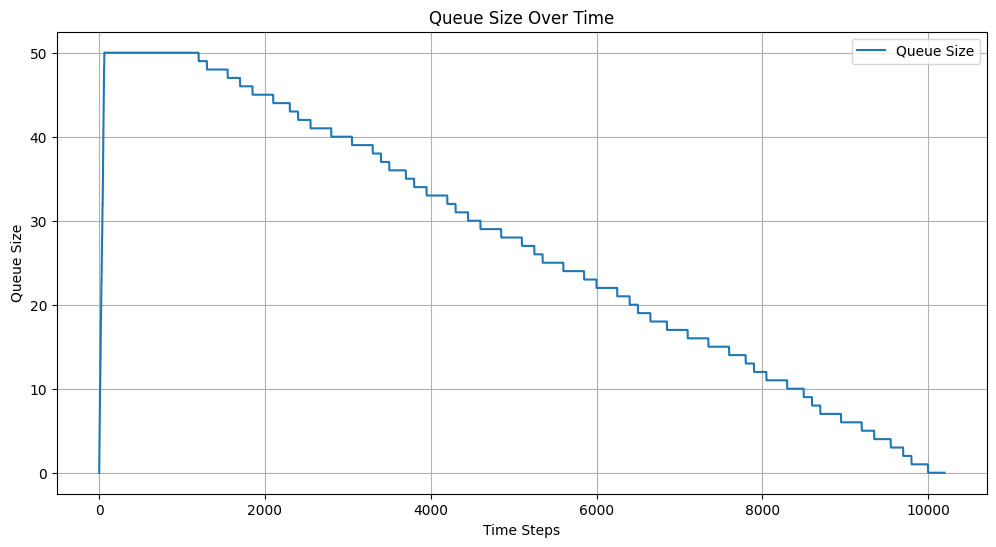

Simulation Results:
Processed Requests: 252
Rejected Requests: 748
Queue Size at End: 0


In [9]:
random.seed(42)

simulation = Simulation(num_clients=1000, num_requests_per_client=1, max_queue_size=50)
simulation.run()